# ⚡ XGBoost — Extreme Gradient Boosting

> **Part of:** Basics → Ensemble_Methods → Boosting

---

## 📌 Boosting Kya Hai?

**Boosting** ek ensemble technique hai jisme:
- Models **sequentially** train hote hain
- Har naya model **pichle model ki galtiyon** ko fix karta hai
- Yeh **bias reduce** karta hai

```
Data → Tree 1 → Errors
              ↓
       Tree 2 (fixes Tree 1 errors) → Errors
              ↓
       Tree 3 (fixes Tree 2 errors) → Errors
              ↓
       Final = Tree1 + Tree2 + Tree3 (weighted sum)
```

---

## 🔥 Boosting Evolution

| Algorithm | Year | Key Idea |
|---|---|---|
| AdaBoost | 1996 | Misclassified samples ko zyada weight do |
| Gradient Boosting | 2001 | Gradient descent se residuals fit karo |
| **XGBoost** | **2014** | **Regularization + Speed + Missing values handle** |
| LightGBM | 2017 | Leaf-wise growth, faster on large data |
| CatBoost | 2017 | Categorical features natively handle |

---

## ⚡ XGBoost Kyu Better Hai?

✅ Built-in **L1 + L2 Regularization** (overfitting control)  
✅ **Missing values** automatically handle karta hai  
✅ **Parallel processing** — fast training  
✅ **Tree pruning** — max_depth se nahi, gain se prune karta hai  
✅ Kaggle competitions mein most used algorithm  

---
## 📦 Step 1 — Install & Import

In [2]:
# !pip install xgboost scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier, plot_importance, plot_tree

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')
import xgboost
print(f'XGBoost version: {xgboost.__version__}')

✅ Libraries imported successfully!
XGBoost version: 3.2.0


---
## 📊 Step 2 — Load & Explore Dataset

In [3]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Dataset Shape  :', X.shape)
print('Classes        :', data.target_names)
print('\nClass Distribution:')
print(y.value_counts())
print('\nFirst 5 rows:')
X.head()

Dataset Shape  : (569, 30)
Classes        : ['malignant' 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## ✂️ Step 3 — Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 455
Testing  samples : 114


---
## 🤖 Step 4 — Train Basic XGBoost Model

In [5]:
xgb = XGBClassifier(
    n_estimators=100,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=4,            # max depth of each tree
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'✅ XGBoost Accuracy: {acc:.4f}')
print(f'✅ AUC-ROC Score   : {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))

✅ XGBoost Accuracy: 0.9474
✅ AUC-ROC Score   : 0.9934

📋 Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



---
## 📉 Step 5 — Confusion Matrix

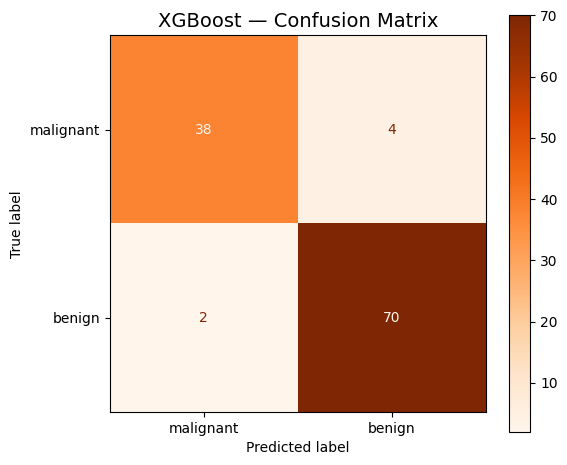

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=data.target_names,
    cmap='Oranges', ax=ax
)
plt.title('XGBoost — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
## 📈 Step 6 — ROC Curve

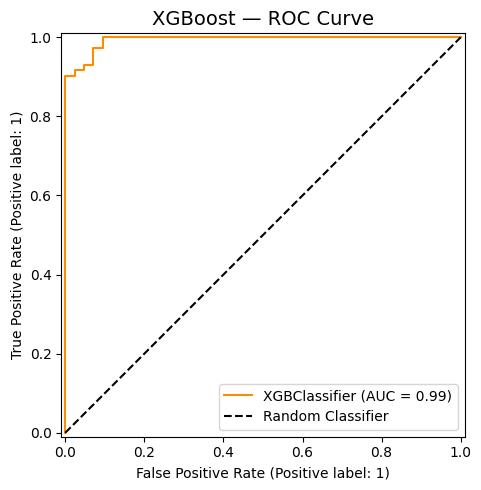

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=ax, color='darkorange')
ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.title('XGBoost — ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

---
## 📊 Step 7 — Feature Importance

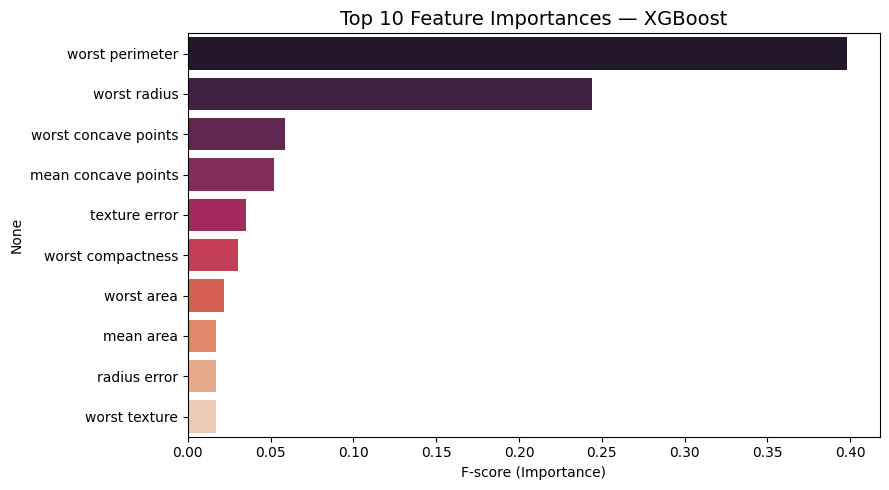

In [8]:
# Plot using sklearn-style
importances = pd.Series(xgb.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette='rocket')
plt.title('Top 10 Feature Importances — XGBoost', fontsize=14)
plt.xlabel('F-score (Importance)')
plt.tight_layout()
plt.show()

---
## 🛑 Step 8 — Early Stopping

> Early stopping: Implement early stopping to prevent overfitting once the validation loss plateaus.

In [9]:
xgb_es = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,   # 20 rounds mein improvement nahi → stop
    random_state=42
)

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'Best iteration     : {xgb_es.best_iteration}')
print(f'Best score         : {xgb_es.best_score:.4f}')
print(f'Accuracy           : {accuracy_score(y_test, xgb_es.predict(X_test)):.4f}')

Best iteration     : 115
Best score         : 0.1020
Accuracy           : 0.9474
